# Libraries

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import StringIndexer
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.types import ArrayType, StringType
import matplotlib.pyplot as plt


# Loading Data from HDFS

In [2]:
ss = SparkSession.builder.appName("infs3208project").getOrCreate()

In [3]:
books_data_path = "hdfs://namenode:9000/books_data.csv"
books_rating_path = "hdfs://namenode:9000/Books_rating.csv"

In [4]:
df_bd = (
    ss.read.option("header", "true")
    .option("quote", "\"")       
    .option("escape", "\"")      
    .option("multiLine", True)   
    .csv(books_data_path)
)

df_br = (
    ss.read.option("header", "true")
    .option("quote", "\"")       
    .option("escape", "\"")      
    .option("multiLine", True)   
    .csv(books_rating_path)
)

In [ ]:
cols_bd = ["title","authors", "categories"]
cols_br = ["Id", "Title","User_id", "review/score", "review/helpfulness"]

(df_bd.select(*cols_bd).write.mode("overwrite").option("compression","snappy").parquet("/tmp/df_bd_pq"))
(df_br.select(*cols_br).write.mode("overwrite").option("compression","snappy").parquet("/tmp/df_br_pq"))



In [14]:
df_bd = ss.read.parquet("/tmp/df_bd_pq")
df_br = ss.read.parquet("/tmp/df_br_pq")

In [ ]:
df_br.printSchema()

In [ ]:
df_bd.printSchema()

# Data Pre-processing

Filtering Books_ratings data with only fiction books

In [15]:
# 0) Pick title column
title_col = "title" if "title" in df_bd.columns else "Title"

# 1) Normalize minimal fields and filter to fiction/children (exclude non-fiction/nonfiction)
df_bd_step1 = (
    df_bd
    .withColumn("title_lc", F.lower(F.trim(F.col(title_col))))
    .withColumn("cat_lc",   F.lower(F.trim(F.col("categories").cast("string"))))
    .filter(F.col("title_lc").isNotNull() & (F.col("title_lc") != ""))
    .filter(
        (F.col("cat_lc").contains("fiction") | F.col("cat_lc").contains("children")) &
        ~(F.col("cat_lc").rlike(r"non[- ]?fiction") | F.col("cat_lc").contains("nonfiction"))
    )
)

# 2) Keep 1 row per title (include authors; if duplicates exist, keep the first encountered)
df_bd_unique = (
    df_bd_step1
    .select("title_lc", F.col(title_col).alias("title_original"), "authors")
    .dropDuplicates(["title_lc"])
)

# List of titles for the join
fiction_titles = df_bd_unique.select(F.col("title_lc").alias("Title"))

# 3) Filter df_br by this list (normalize review titles the same way)
df_br_filtered = (
    df_br
    .withColumn("Title", F.lower(F.trim(F.col("Title"))))
    .join(fiction_titles, on="Title", how="inner")
)

In [ ]:
row_count = df_br_filtered.count()
print("Rows in df_br after filtering to fiction (excluding nonfiction):", row_count)

In [ ]:

review_counts = (
    df_br_filtered
    .groupBy("Title")
    .agg(F.count("*").alias("num_reviews"))
)

# Join the counts back and keep only titles with ≥ 50 reviews
df_br_filtered = (
    df_br_filtered
    .join(review_counts, on="Title", how="inner")
    .filter(F.col("num_reviews") >= 1000)
)

df_br_filtered = (
    df_br_filtered
    #ensure book review has a score
    .filter(F.col("review/score").isNotNull() & (F.col("review/score") != ""))
    #ensure book review was a notable review
    .filter(F.col("review/helpfulness").isNotNull() & (F.col("review/helpfulness") != ""))
    #ensure helpfulness column is not empty
    .filter(F.col("review/helpfulness").rlike(r"^\d+/\d+$"))
    #ensures rating score is data type of double
    .withColumn("rating", F.col("review/score").cast("double"))
    #retrieve votes of helpfulness column
    .withColumn("helpful_votes", F.split(F.col("review/helpfulness"), "/").getItem(0).cast("double"))
     #retrieve total possible votes of helpfulness column
    .withColumn("total_votes", F.split(F.col("review/helpfulness"), "/").getItem(1).cast("double"))
    #create helpfulness ratio
    .withColumn("helpfulness_ratio",
        F.when(F.col("total_votes") > 0, F.col("helpful_votes") / F.col("total_votes"))
         .otherwise(0.0)
    )
    #ensures that rating is between 1 and 5
    .filter((F.col("rating") >= 1.0) & (F.col("rating") <= 5.0))
)


df_br_filtered = df_br_filtered.filter((F.col("total_votes") >= 1) & (F.col("helpfulness_ratio") >= 0.5))

#check to see how many rows is filtered to
row_count = df_br_filtered.count()
print("Rows in df_br after filtering to fiction (excluding nonfiction):", row_count)

del df_br
del df_bd

#create a columnar storage format
# (df_br_filtered
#  .write.mode("overwrite").option("compression","snappy")
#  .parquet("/tmp/reviews_filtered_fiction"))  


In [5]:
df_br_filtered = ss.read.parquet("/tmp/reviews_filtered_fiction")

In [6]:

ratings = (
    df_br_filtered
    .select(
        F.col("User_id").alias("user_str"),
        F.col("Title").alias("item_str"),
        F.col("rating").cast("double")  
    )
    .dropna(subset=["user_str","item_str","rating"])
)

In [7]:

#creates list of ids for title

#converts string ids to numerical ids
u_indexer = StringIndexer(inputCol="user_str", outputCol="userId", handleInvalid="skip").fit(ratings)
i_indexer = StringIndexer(inputCol="item_str", outputCol="itemId", handleInvalid="skip").fit(ratings)

#create ratings dataframe to contain numerical ids
ratings_i = (
    i_indexer.transform(u_indexer.transform(ratings))
    .select("userId","itemId","rating")
    .cache()
)



# Spark programming - Colloborative Filtering (ALS)

In [8]:
#creating training and test sets
train, test = ratings_i.randomSplit([0.8, 0.2], seed=42)

In [9]:

#ALS model
als = ALS(
    userCol="userId", itemCol="itemId", ratingCol="rating",
    nonnegative=True, implicitPrefs=False, 
    rank=64, regParam=0.08, maxIter=15,
    coldStartStrategy="drop"  
)

#fitting Model
model = als.fit(train)

# Evaulation
pred = model.transform(test)
rmse = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction").evaluate(pred)
print(f"RMSE: {rmse:.4f}")

RMSE: 0.3439


In [10]:
# Top-10 recommendations for every user
user_recs = model.recommendForAllUsers(50)

# Explode and keep (userId, itemId, predicted_rating)
user_recs_exploded = (
    user_recs
    .withColumn("rec", F.explode("recommendations"))
    .select("userId",
            F.col("rec.itemId").alias("itemId"),
            F.col("rec.rating").alias("predicted_rating"))
)

# Count how many times each item appears in top-10 lists
item_counts = (
    user_recs_exploded
    .groupBy("itemId")
    .agg(F.count("*").alias("times_recommended"),
         F.avg("predicted_rating").alias("avg_pred_score"))
    .orderBy(F.col("times_recommended").desc(), F.col("avg_pred_score").desc())
)

In [11]:
# StringIndexer labels are a Python list; build a tiny lookup DF
item_map = ss.createDataFrame(
    [(float(i), lab) for i, lab in enumerate(i_indexer.labels)],  # match indexer dtype
    ["itemId", "Title"]
)

top_items = (
    item_counts
    .withColumn("itemId", F.col("itemId").cast("double"))
    .join(item_map, on="itemId", how="left")
    .select("Title", "itemId", "times_recommended", "avg_pred_score")
    .orderBy(F.col("times_recommended").desc(), F.col("avg_pred_score").desc())
)

In [12]:
top10 = top_items.limit(10)
top10.show(truncate=False)

+----------------------------------------------+------+-----------------+------------------+
|Title                                         |itemId|times_recommended|avg_pred_score    |
+----------------------------------------------+------+-----------------+------------------+
|the fellowship of the ring                    |136.0 |29753            |3.4592059558208694|
|lonesome dove                                 |100.0 |29466            |3.542788379277149 |
|the wonderful wizard of oz                    |144.0 |28116            |3.5476671828197914|
|the call of the wild                          |135.0 |27795            |3.457604463959495 |
|animal farm 50th anniversary edition          |106.0 |27731            |3.429188604661103 |
|charlotte's web                               |99.0  |27247            |3.48019749911443  |
|a christmas carol (enriched classics (pocket))|132.0 |27018            |3.4193762007931703|
|the grapes of wrath                           |76.0  |26759          

In [16]:
top_items_norm = top_items.withColumn("title_lc", F.lower(F.trim(F.col("Title"))))

# 2) Join to bring in authors
items_with_authors = (
    top_items_norm
    .join(df_bd_unique.select("title_lc", "authors"), on="title_lc", how="left")
)

# 3) Parse authors into an array, whether it's already ArrayType or a string like "['A','B']"
if isinstance(df_bd_unique.schema["authors"].dataType, ArrayType):
    items_with_authors = items_with_authors.withColumn("authors_arr", F.col("authors"))
else:
    # Try JSON parse first, fallback to a simple bracket/quote cleanup + split on comma
    items_with_authors = (
        items_with_authors
        .withColumn(
            "authors_arr_json",
            F.from_json(F.col("authors"), ArrayType(StringType()))
        )
        .withColumn(
            "authors_arr",
            F.when(F.size(F.col("authors_arr_json")) > 0, F.col("authors_arr_json"))
             .otherwise(
                 F.split(
                     F.regexp_replace(
                         F.regexp_replace(F.col("authors"), r"^\s*\[|\]\s*$", ""),  # trim [ ]
                         r"[\"']", ""                                               # drop quotes
                     ),
                     r"\s*,\s*"
                 )
             )
        )
        .drop("authors_arr_json")
    )

# 4) Explode authors; clean names; drop empties
authors_exploded = (
    items_with_authors
    .withColumn("author", F.explode_outer("authors_arr"))
    .withColumn("author", F.trim(F.col("author")))
    .filter(F.col("author").isNotNull() & (F.col("author") != ""))
)

# 5) Aggregate votes PER AUTHOR (weighted by times_recommended)
top_authors = (
    authors_exploded
    .groupBy("author")
    .agg(
        F.sum("times_recommended").alias("author_votes"),
        F.countDistinct("Title").alias("unique_books_contributing")
    )
    .orderBy(F.col("author_votes").desc(), F.col("unique_books_contributing").desc())
    .limit(10)
)

top_authors.show(truncate=False)

+-------------------------+------------+-------------------------+
|author                   |author_votes|unique_books_contributing|
+-------------------------+------------+-------------------------+
|Charles Dickens          |94220       |4                        |
|George Orwell            |72039       |3                        |
|John Steinbeck           |63904       |5                        |
|Richard Adams            |52392       |2                        |
|Mark Twain               |46331       |3                        |
|J.R.R. Tolkien           |41211       |2                        |
|J. K. Rowling            |37751       |2                        |
|John Ronald Reuel Tolkien|34189       |2                        |
|Lewis Carroll            |33924       |2                        |
|Kurt Vonnegut            |33423       |4                        |
+-------------------------+------------+-------------------------+



# Visualisations of Model and Results

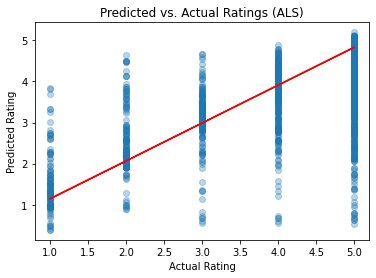

Slope: 0.921, Intercept: 0.222


In [19]:
import numpy as np
import matplotlib.pyplot as plt


pdf = pred.select("rating", "prediction").toPandas()
# convert to numpy arrays
x = pdf["rating"]
y = pdf["prediction"]

# fit a linear regression line y = a*x + b
a, b = np.polyfit(x, y, 1)

# scatter plot
plt.scatter(x, y, alpha=0.3)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Predicted vs. Actual Ratings (ALS)")

# add regression line
plt.plot(x, a*x + b, color="red", label=f"Trend line: y={a:.2f}x+{b:.2f}")

plt.show()

print(f"Slope: {a:.3f}, Intercept: {b:.3f}")


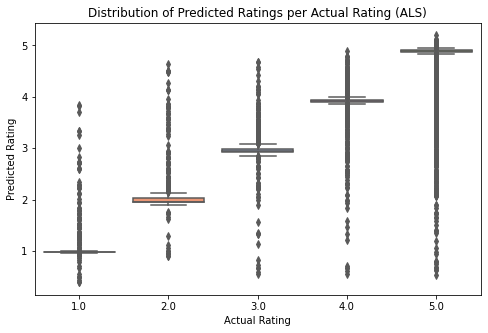

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create boxplots of predicted ratings grouped by actual rating
plt.figure(figsize=(8,5))
sns.boxplot(x="rating", y="prediction", data=pdf, palette="Set2")

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Distribution of Predicted Ratings per Actual Rating (ALS)")
plt.show()


In [ ]:
pdf["error"] = pdf["rating"] - pdf["prediction"]
plt.hist(pdf["error"], bins=100, edgecolor='black')
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Distribution of Prediction Errors")
plt.xlim(-1, 1)
plt.show()

In [ ]:
top_items_pd = top_items.toPandas()
plt.barh(top_items_pd["Title"].head(10), top_items_pd["times_recommended"].head(10))
plt.xlabel("Times Recommended")
plt.title("Top 15 Most Recommended Books")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
top_authors_pd = top_authors.toPandas()
plt.barh(top_authors_pd["author"].head(10), top_authors_pd["author_votes"].head(10))
plt.xlabel("Total Recommendation Votes")
plt.title("Top 10 Most Recommended Authors")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
ss.stop()